# **Clinical Trial Success Prediction: Production Engine (v42.0)**

This notebook serves as the **Official Production Engine**. It builds the final predictive model used to feed the FastAPI service and the Streamlit application with XGBoost weights, Therapeutic Area-specific thresholds, and explainability artifacts.

### **Key Production Objectives:**
1. **Full-Universe Training (2009–2022)**: Training on the complete historical cohort to maximize signal.
2. **Recency-Weighted Calibration**: Optimizing decision boundaries using temporal weights.
3. **Global Explainability Export**: Generating SHAP values for all ~29,557 records.
4. **Artifact Persistence**: Saving the model, thresholds, and registry for deployment.

#### <REF:ENV_CONFIG>
> #### **1. Development Environment Configuration**

To ensure a seamless development workflow, we configure dynamic module reloading and precision-focused warning filters. This allows for iterative refinement of the `src` modules without requiring kernel restarts.

In [43]:
# <REF:ENV_CONFIG_CODE>
# --- AUTO-RELOAD MAGIC COMMANDS ---
%load_ext autoreload
%autoreload 2

import warnings
# 1. Initialize TQDM for Pandas (Enables progress_apply)
from tqdm.auto import tqdm
tqdm.pandas()

# 2. Silence Warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# <REF:/ENV_CONFIG_CODE>


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### <REF:PATH_RESOLUTION>
> #### **2. Project Path Resolution and Dynamic Imports**

*   **Dynamic Root Detection:** Implements a filesystem traversal algorithm to automatically locate the project root by searching for the `src` directory, ensuring portability across different environments (local vs. cloud).
*   **Environment Path Augmentation:** Appends the identified root directory to the system’s `PYTHONPATH`, enabling the usage of absolute imports (e.g., `import src.etl`) regardless of the notebook's location.
*   **Directory Standardization:** Defines and verifies global path constants (`DATA_PATH`, `MODELS_PATH`) to ensure consistent file I/O operations throughout the pipeline.

***

<REF:/PATH_RESOLUTION>

In [44]:
# <REF:PATH_RESOLUTION_CODE>
import sys
from pathlib import Path

# 1. Define the Project Root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"
FRONTEND_DATA_PATH = project_root / "frontend" / "data"

# 4. Verification
print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

# <REF:/PATH_RESOLUTION_CODE>


Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


#### <REF:LIB_INIT>
> #### **3. Library and Custom Module Initialization**

*   **Analytical Framework Setup:** Imports the foundational Python libraries for structured data manipulation (`pandas`, `numpy`) and statistical visualization (`matplotlib`, `seaborn`).
*   **Domain-Specific Module Import:**
    *   Initializes the `ClinicalTrialLoader`: The custom ETL engine responsible for ingesting raw AACT data, enforcing inclusion criteria, and executing domain-specific feature engineering.
    *   Initializes the `preprocessor`: The pipeline factory that constructs the `ColumnTransformer` for rigorous feature scaling, encoding, and dimensionality reduction.
    *   Imports `FEATURE_REGISTRY` and `UI_SCHEMA`: Logic-locked metadata stores defining feature types, encoding strategies, and UI display hierarchies.
    *   Imports `append_new_embeddings`: Orchestrator for merging external BioBERT vectors from Colab into the local feature store.

***

<REF:/LIB_INIT>


In [45]:
# <REF:LIB_INIT_CODE>
import os
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Custom Modules/Classes
from src.prep.data_loader_clinpred import ClinicalTrialLoader
from src.prep.pipeline import preprocessor, FEATURE_REGISTRY, UI_SCHEMA
#emb: Orchestrator for merging external BioBERT vectors from Colab into the local feature store.
# from src.prep.append_embeddings import append_new_embeddings

load_dotenv()

# <REF:/LIB_INIT_CODE>


True

#### <REF:DATA_PIPELINE>\n
> #### **4.A Automated Data Pipeline & Workflow Integrity**\n
\n
The pipeline executes a multi-stage ETL process to generate the analytical cohort. It begins with **Automated NLP Sync** to merge new embeddings from Colab if present. It then prioritizes `data_clinpred.csv` as the **Production Source of Truth (v19.0)**, falling back to full ingestion only if the cached feature store is missing.\n

In [46]:
# <REF:DATA_PIPELINE_CODE>
from dotenv import load_dotenv
#emb: Sync logic disabled
# from src.prep.append_embeddings import append_new_embeddings

# Load Environment Variables (.env)
load_dotenv()

# 1. AUTOMATED NLP SYNC: Merge new embeddings from Colab if present
#emb: Automated sync of Colab vectors disabled
# append_new_embeddings(str(DATA_PATH))

# 2. DATA LOADING & 'OFFLINE FEATURE STORE' CHECK
DATA_CLINPRED_PATH = DATA_PATH / "data_clinpred.csv"

if DATA_CLINPRED_PATH.exists():
    df_full = pd.read_csv(DATA_CLINPRED_PATH, low_memory=False)
    print(">>> Loaded Production Universe | Shape: " + str(df_full.shape))
else:
    print(">>> data_clinpred.csv not found. Initializing full Production Ingestion...")
    loader = ClinicalTrialLoader(str(DATA_PATH))
    df_full = loader.load_base_data()
    df_full = loader.add_features(df_full)
    #emb: NLP coverage check and export disabled
    # loader.check_and_export_nlp(df_full)
    df_full.to_csv(DATA_CLINPRED_PATH, index=False)
    print(">>> Production Data Loaded & Saved. Final Shape: " + str(df_full.shape))


print(f"    Total Universe: {len(df_full):,} trials")
# <REF:/DATA_PIPELINE_CODE>


>>> Loaded Production Universe | Shape: (29556, 156)
    Total Universe: 29,556 trials


#### <REF:DATA_AUDIT>
> #### **4.B Forensic Data Audit: Integrity & Schema Verification**

Before modeling, we execute a forensic audit to ensure dataset completeness. This phase checks for row loss during CSV parsing, enforces critical numeric types, and verifies the density of the NLP feature store.

In [47]:
# <REF:DATA_AUDIT_CODE>
import pandas as pd
import numpy as np
import os
import sys

# --- CONFIGURATION ---
FILE_PATH = DATA_PATH / "data_clinpred.csv"

def audit_data_integrity():
    print("="*100)
    print(f"FORENSIC DATA AUDIT: {os.path.basename(FILE_PATH)}")
    print("="*100)

    if not FILE_PATH.exists():
        print(f"[CRITICAL] File not found at: {FILE_PATH}")
        return

    # 1. THE "SKIPPED LINE" CHECK (Raw vs Parsed)
    print(">>> Phase 1: Integrity Check (Did we lose rows?)")
    with open(FILE_PATH, 'rb') as f: raw_line_count = sum(1 for _ in f)
    df_full = pd.read_csv(FILE_PATH, low_memory=False)
    df_rows = len(df_full)
    expected_rows = raw_line_count - 1
    diff = expected_rows - df_rows

    print(f"    Raw File Lines:      {raw_line_count:,}")
    print(f"    DataFrame Rows:      {df_rows:,}")

    if diff == 0: print("    [PASS] Perfect Match. No lines skipped.")
    else: print(f"    [WARN] Discrepancy: {diff} lines skipped (Check for internal newlines).")

    # 2. CRITICAL COLUMN TYPE CHECK
    print("\n>>> Phase 2: Critical Type Enforcement")
    critical_checks = {
        'start_year': [np.integer, np.floating],
        'target':     [np.integer, np.floating],
        'nct_id':     [object, str]
    }
    for col, valid_types in critical_checks.items():
        if col not in df_full.columns:
            print(f"    [FAIL] Missing Column: {col}")
            continue
        actual_type = df_full[col].dtype
        is_valid = any(np.issubdtype(actual_type, t) for t in valid_types)
        status = "[PASS]" if is_valid else "[FAIL]"
        print(f"    {status} {col:<15} | Type: {actual_type}")

    # 3. EMBEDDING PRESENCE CHECK
    #emb: Embedding check updated to reflect disabled status
    print("\n>>> Phase 3: Feature Store Content (Embeddings DISABLED)")
    # emb_cols = [c for c in df_full.columns if c.startswith('crit_')]
    # if len(emb_cols) > 0:
    #     print(f"    [INFO] Embeddings Detected: {len(emb_cols)} dimensions found.")
    #     sample_sum = df_full[emb_cols[0]].sum()
    #     if sample_sum == 0: print("    [FAIL] Embeddings appear to be all zeros!")
    #     else: print("    [PASS] Embeddings contain non-zero data.")
    # else: print("    [INFO] No Embeddings found (Expected: Embeddings are currently disabled).")

    # 4. DETAILED MISSING VALUE REPORT
    print("\n>>> Phase 4: Detailed Column Scan")
    print("-" * 100)
    print(f"{'COLUMN NAME':<35} | {'DTYPE':<10} | {'MISSING':<8} | {'%':<6} | {'SAMPLE VALUE'}")
    print("-" * 100)
    for col in df_full.columns:
        if col.startswith(('crit_', 'sci_', 'endp_')) and col != 'crit_0': continue
        if col == 'crit_0':
            print(f"{'... [Embeddings Hidden] ...':<35} | {'float':<10} | {'0':<8} | {'0.0%':>4} | {'(Vectors)'}")
            continue
        dtype = str(df_full[col].dtype)
        n_miss = df_full[col].isna().sum()
        pct_miss = (n_miss / len(df_full)) * 100
        sample = df_full[col].dropna().iloc[0] if n_miss < len(df_full) else "ALL NAN"
        sample_str = str(sample)[:25]
        flag = " [!]" if pct_miss > 0 else ""
        print(f"{col:<35} | {dtype:<10} | {n_miss:<8} | {pct_miss:>4.1f}% | {sample_str:<25}{flag}")
    print("-" * 100)

if __name__ == "__main__":
    audit_data_integrity()

# <REF:/DATA_AUDIT_CODE>


FORENSIC DATA AUDIT: data_clinpred.csv
>>> Phase 1: Integrity Check (Did we lose rows?)
    Raw File Lines:      251,844
    DataFrame Rows:      29,556
    [WARN] Discrepancy: 222287 lines skipped (Check for internal newlines).

>>> Phase 2: Critical Type Enforcement
    [PASS] start_year      | Type: float64
    [PASS] target          | Type: float64
    [PASS] nct_id          | Type: object

>>> Phase 3: Feature Store Content (Embeddings DISABLED)

>>> Phase 4: Detailed Column Scan
----------------------------------------------------------------------------------------------------
COLUMN NAME                         | DTYPE      | MISSING  | %      | SAMPLE VALUE
----------------------------------------------------------------------------------------------------
nct_id                              | object     | 0        |  0.0% | NCT02343926              
start_date                          | object     | 0        |  0.0% | 2014-12-31               
completion_date                 

#### <REF:NLP_AUDIT>
> #### **5.A Pre-Computation NLP Signal & Leakage Audit**

This audit scans text fields for 'Day Zero' violations (administrative keywords like 'updated' or NCT IDs) that could cause artificial performance inflation. It also validates the preservation of scientific nomenclature (e.g., RECIST, OS) to ensure the embedding model receives high-signal input.

In [48]:
# <REF:NLP_AUDIT_CODE>
#emb: Forensic NLP Audit disabled as embeddings are not currently used.
# import pandas as pd
# import re
#
# # Source for BioBERT processing (The 'Delta' export file)
# # Note: This file is deleted by append_new_embeddings() after successful merge.
# # If missing, we audit the main 'data_clinpred.csv' instead.
# file_delta = DATA_PATH / "data_clinpred_emb_transform.csv"
# file_main = DATA_PATH / "data_clinpred.csv"
#
# if file_delta.exists():
#     file_to_audit = file_delta
#     audit_mode = "DELTA (Pre-Merge)"
# elif file_main.exists():
#     file_to_audit = file_main
#     audit_mode = "PRODUCTION (Post-Merge)"
# else:
#     file_to_audit = None
#
# if file_to_audit is None:
#     print(f"[!] Audit Skip: No NLP source files found.")
# else:
#     # For large production files, we audit a sample or just the last 1000 rows
#     # to maintain speed while checking for recent leakage patterns.
#     if audit_mode == "PRODUCTION (Post-Merge)":
#         df_audit = pd.read_csv(file_to_audit, low_memory=False).tail(2000)
#     else:
#         df_audit = pd.read_csv(file_to_audit)
#
#     print("="*80); print(f"FORENSIC NLP AUDIT (v17.0 SHIELD) - {audit_mode}"); print("="*80)
#     print(f"Target File: {file_to_audit.name}")
#
#     # 1. INTEGRITY: Multi-Pillar Check
#     text_pillars = ["txt_scientific_essence", "txt_primary_endpoints", "txt_criteria"]
#     print(f"[1] Integrity: Rows Audited={len(df_audit)}")
#     for col in text_pillars:
#         if col in df_audit.columns:
#             missing = df_audit[col].isna().sum()
#             print(f"  - {col:<25} | Missing: {missing}")
#         else:
#             print(f"  - {col:<25} | [MISSING COLUMN]")
#
#     # 2. ZERO-LEAK VIOLATION: Searching for Sample Sizes (N=) in text
#     print("\n[2] Zero-Leak Violation (N= / Sample Size markers):")
#     leak_pattern = r"\b(?:N\s*=\s*\d+|enrollment\s*of\s*\d+|sample\s*size\s*\d+)\b"
#     total_leaks = 0
#     for col in text_pillars:
#         if col in df_audit.columns:
#             leaks = df_audit[col].astype(str).str.contains(leak_pattern, case=False, regex=True).sum()
#             print(f"  - {col:<25}: {leaks} leaks detected")
#             total_leaks += leaks
#
#     # 3. ADMINISTRATIVE LEAKAGE: Searching for 'after-the-fact' markers
#     leakage_keywords = ["amendment", "protocol v", "version", "updated", "modified", "clinicaltrials.gov"]
#     print("[3] Administrative Markers (Lower is better):")
#     for word in leakage_keywords:
#         if "txt_criteria" in df_audit.columns:
#             count = df_audit["txt_criteria"].astype(str).str.contains(re.escape(word), case=False).sum()
#             print(f"  - '{word}': {count}")
#
#     # 4. SCIENTIFIC SIGNAL: Validating clinical nomenclature retention
#     print("[4] Scientific Signal Preservation (Clinical Rigor):")
#     protected = ["RECIST", "HbA1c", "ECOG", "NYHA", "mg/kg", "ORR", "OS"]
#     for term in protected:
#         if "txt_criteria" in df_audit.columns:
#             count = df_audit["txt_criteria"].astype(str).str.contains(re.escape(term), case=False).sum()
#             print(f"  - '{term}': {count}")
#
#     print("" + "="*80)
#     if total_leaks > 0:
#         print(f"AUDIT COMPLETE: [WARN] {total_leaks} Leakage points found in {audit_mode} sample.")
#     else:
#         print(f"AUDIT COMPLETE: [PASS] No major leakage violations detected in {audit_mode} sample.")
#     print("="*80)
# <REF:/NLP_AUDIT_CODE>


#### <REF:TEMP_SPLIT>
> #### **5. Production Temporal Split: Cohort Extraction & Identity Anchoring**

Extracts the historical training cohort from the universal universe and promotes the NCT_ID to the index to act as the permanent identity anchor for scoring and SHAP attributions.

In [49]:
# <REF:TEMP_SPLIT_CODE>
# 1. PRODUCTION FILTERING (Extract Historical Training Cohort) & Identity Anchoring
PROD_START_YEAR = int(os.getenv('PROD_START_YEAR', 2009))
PROD_END_YEAR   = int(os.getenv('PROD_END_YEAR', 2022))

# Note: df_full already has nct_id as its index from the Load step
df_train = df_full[df_full['target'].notna()].copy()

# Promote NCT_ID as Identity Anchor if not already
if df_train.index.name != 'nct_id':
    df_train = df_train.set_index('nct_id')

df_train = df_train[df_train['start_year'].between(PROD_START_YEAR, PROD_END_YEAR)].copy()

# Sort by date for temporal consistency
df_train['start_date'] = pd.to_datetime(df_train['start_date'], errors='coerce')
df_train = df_train.sort_values('start_date')

# 2. Identify Model features
#emb: Embedding columns (crit_, sci_, endp_) are currently disabled
cols_to_keep = [c for c in df_train.columns if c.endswith('_ml') or
                # c.startswith(('crit_', 'sci_', 'endp_')) or
                c == 'therapeutic_area']

# 3. Anchored Training Matrix
X_train = df_train[cols_to_keep]
y_train = df_train['target']

# 4. Preparation of df_full for Inference (Promote NCT_ID to index)
if df_full.index.name != 'nct_id':
    df_full = df_full.set_index('nct_id')

print(f'>>> Production Training Set Prepared: {len(X_train):,} trials ({PROD_START_YEAR}-{PROD_END_YEAR})')
print(f'    Identity Anchor: Index is {X_train.index.name}')
# <REF:/TEMP_SPLIT_CODE>


>>> Production Training Set Prepared: 24,191 trials (2009-2022)
    Identity Anchor: Index is nct_id


#### <REF:MODEL_TRAIN>
> #### **7. Model Configuration: XGBoost with Class Balancing**

We utilize an XGBoost classifier with strict regularization (shallow trees, high alpha/lambda) to prioritize broad, generalizable patterns over noise. To handle the natural class imbalance (trials succeed more often than they fail), we calculate `scale_pos_weight`, forcing the model to pay more attention to the minority failure class.

In [50]:
# <REF:MODEL_TRAIN_CODE>
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from src.prep.pipeline import preprocessor

print('\n=== STEP 7: TRAINING MODEL ===')

# Imbalance Handling: Ratio of Successes to Failures
n_pos = y_train.sum(); ratio = (len(y_train) - n_pos) / n_pos

# Balanced Champion Hyperparameters (v33.1)
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=4,
    min_child_weight=15, gamma=4, subsample=0.8,
    colsample_bytree=0.50, reg_alpha=15, reg_lambda=15,
    scale_pos_weight=ratio, tree_method='hist', eval_metric='logloss',
    n_jobs=-1, random_state=42, enable_categorical=False
)

model = Pipeline([('prep', preprocessor()), ('clf', xgb)])

print('>>> Fitting Model Pipeline...')
model.fit(X_train, y_train)
print('    [DONE] Training complete.')
# <REF:/MODEL_TRAIN_CODE>



=== STEP 7: TRAINING MODEL ===
>>> Fitting Model Pipeline...
    [DONE] Training complete.


#### <REF:CORE_PERF>
> #### **5.B Production Portfolio Performance Audit**

Evaluates the champion model's performance across the full historical portfolio (2009–2022).

In [51]:
# <REF:CORE_PERF_CODE>
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# 1. Full Portfolio Training Results (2009-2022)
y_prob_train = model.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_prob_train)
y_pred_train = (y_prob_train > 0.5).astype(int)
acc_train = accuracy_score(y_train, y_pred_train)

print(f"\n=== PRODUCTION PORTFOLIO RESULTS (2009-2022) ===")
print(f"TRAIN AUC: {auc_train:.4f}")
print(f"TRAIN ACC: {acc_train:.4f} (at 0.5 threshold)")

print("\nClassification Report (Full Historical Set):")
print(classification_report(y_train, y_pred_train))
# <REF:/CORE_PERF_CODE>



=== PRODUCTION PORTFOLIO RESULTS (2009-2022) ===
TRAIN AUC: 0.7287
TRAIN ACC: 0.6482 (at 0.5 threshold)

Classification Report (Full Historical Set):
              precision    recall  f1-score   support

         0.0       0.90      0.63      0.74     19330
         1.0       0.33      0.71      0.45      4861

    accuracy                           0.65     24191
   macro avg       0.61      0.67      0.59     24191
weighted avg       0.78      0.65      0.68     24191



#### <REF:PRED_GEN>
> #### **8. Global Prediction Generation**

Computes success probabilities for the total universe of trials (both historical and ongoing) to enable search and portfolio-wide analysis.

In [52]:
# <REF:PRED_GEN_CODE>
# Generate predictions for the TOTAL UNIVERSE (Historical + Ongoing)
y_prob_full = model.predict_proba(df_full[cols_to_keep])[:, 1]
# <REF:/PRED_GEN_CODE>


#### <REF:POLICY_OPT>
> #### **8.B Decision Policy Validation (Honesty Check)**

Before finalizing thresholds, we validate our chosen policy (**$\beta = 1.10$**, **$N = 500$**). This ensures that our philosophical preference for Recall (Coverage) results in a stable signal in the most recent historical era, prioritizing the interception of failures while maintaining acceptable precision.


In [53]:
# <REF:POLICY_ANCHORS_CODE>
# --- GLOBAL STRATEGY KNOBS ---
F1_calibration = 1.10     # The 'Beta'. < 1.0 favors Precision, > 1.0 favors Recall.
min_samples_policy = 500   # Min trials needed for a TA to get its own threshold.
w_floor, w_ceil = 0.1, 1.0 # Recency Weighting: Oldest (0.1) to Newest (1.0).


In [54]:
def find_optimal_threshold(y_true, y_probs, beta=1.0, weights=None):
    """
    Finds threshold maximizing F-beta score.
    Optional 'weights' parameter allows for temporal recency bias.
    """
    import numpy as np
    from sklearn.metrics import precision_recall_curve

    # Weights impact the Precision/Recall points calculation
    p, r, t = precision_recall_curve(y_true, y_probs, sample_weight=weights)
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)

    return t[np.argmax(f[:-1])] if len(t) > 0 else 0.5


#### <REF:DYN_THRESH>
> #### **9. Unified Dynamic Threshold Calibration (Recency-Weighted In-Sample)**

This module implements **Granular Thresholding** using the full training cohort. It ensures decision boundaries are sensitive to the unique risk profiles of different Therapeutic Areas (TAs).

**The Recency-Weighted Logic:** To ensure the model is optimized for the modern clinical landscape, we apply temporal weights to the training data. Trials from the early era (2009) carry a lower weight (e.g., 0.1), while the most recent trials (2022) carry full weight (1.0). This forces the threshold optimization algorithm to prioritize contemporary success/failure patterns while still utilizing the full volume of historical data for stability. TAs with insufficient modern data default to the Global Pool Threshold to prevent noise-driven overfitting.


In [55]:
# <REF:DYN_THRESH_CODE>
import json
import pandas as pd
import numpy as np
from scipy.special import logit

print('=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===')
# --- SYNC LOGIC: Inheriting Knobs from Anchor Cell ---
print(f'>>> Policy: Beta={F1_calibration} | Recency Bias: {w_floor} to {w_ceil}')

# 1. GENERATE PREDICTIONS & DYNAMIC WEIGHTS
y_prob_train = model.predict_proba(X_train)[:, 1]
train_years = df_train['start_year']
y_min, y_max = train_years.min(), train_years.max()

# --- SYNC LOGIC: Recency formula using global knobs ---
train_weights = w_floor + (w_ceil - w_floor) * (train_years - y_min) / (y_max - y_min)

df_cal = pd.DataFrame({
    'TA': X_train['therapeutic_area'],
    'true': y_train.values,
    'prob': y_prob_train,
    'weight': train_weights
})

# 2. CALCULATE WEIGHTED THRESHOLDS
global_thresh = find_optimal_threshold(df_cal['true'], df_cal['prob'], beta=F1_calibration, weights=df_cal['weight'])
# --- SYNC LOGIC: Logit Conversion for Step 7 ---
global_logit = float(logit(np.clip(global_thresh, 1e-5, 1-1e-5)))

print('')
print(f'🌍 Global Pool Threshold: {global_thresh:.4f} (Logit: {global_logit:.4f})')

final_thresholds = {}
final_threshold_logits = {}
audit_log = []
ta_counts = df_cal['TA'].value_counts()

for ta, count in ta_counts.items():
    df_ta = df_cal[df_cal['TA'] == ta]
    weighted_n = df_ta['weight'].sum() # Audit Impact of Recency Weights

    if count < min_samples_policy:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    if len(df_ta['true'].unique()) <= 1:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    t_ta = find_optimal_threshold(df_ta['true'], df_ta['prob'], beta=F1_calibration, weights=df_ta['weight'])
    t_ta_clipped = np.clip(t_ta, 1e-5, 1-1e-5)

    final_thresholds[ta] = t_ta
    final_threshold_logits[ta] = float(logit(t_ta_clipped))
    audit_log.append({'TA': ta, 'Raw_N': count, 'Eff_N': f"{weighted_n:.1f}", 'Threshold': t_ta})

# 3. SAVE ARTIFACTS
cal_arts = {
    'model_version': 'recency_weighted_v4.1_synced',
    'beta': F1_calibration,
    'recency_range': [w_floor, w_ceil],
    'global_threshold': float(global_thresh),
    'ta_thresholds': {ta: float(t) for ta, t in final_thresholds.items()},
    'ta_threshold_logits': final_threshold_logits
}
with open('calibration_granular_model_validation.json', 'w') as f: json.dump(cal_arts, f, indent=2)

print('')
print('--- CALIBRATION REPORT (WEIGHTED EFF_N) ---')
print(pd.DataFrame(audit_log).to_string(index=False))

print('')

# <REF:/DYN_THRESH_CODE>


=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===
>>> Policy: Beta=1.1 | Recency Bias: 0.1 to 1.0

🌍 Global Pool Threshold: 0.4957 (Logit: -0.0173)

--- CALIBRATION REPORT (WEIGHTED EFF_N) ---
              TA  Raw_N  Eff_N  Threshold
        ONCOLOGY   4704 2468.3   0.601976
      INFECTIONS   2522 1470.6   0.434955
       NEUROLOGY   1887 1010.7   0.554682
     DERMATOLOGY   1846 1049.2   0.384165
GASTROINTESTINAL   1817  910.1   0.527252
 MUSCULOSKELETAL   1577  764.1   0.478136
     RESPIRATORY   1568  714.0   0.423666
       METABOLIC   1509  716.4   0.479903
  CARDIOVASCULAR   1273  620.4   0.515107
   OPHTHALMOLOGY   1162  647.5   0.452531
      PSYCHIATRY    974  480.2   0.485422
   RENAL/UROLOGY    947  463.0   0.479006
      HEMATOLOGY    762  424.2   0.573840



#### <REF:CALIBRATION_AUDIT>
> #### **11. Comprehensive Therapeutic Area Calibration Audit**

Validates model stability and strategy efficiency by comparing the **Full Portfolio (2009-2022)** against the **Modern Era (2021-2022)**. This ensures that TA-specific thresholds remain robust under contemporary clinical volatility.

In [56]:
# <REF:CALIBRATION_AUDIT_CODE>
from sklearn.metrics import precision_score, recall_score, roc_auc_score

print('>>> STEP 11: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...')
print('[SCOPE] Full Columns:   2009-2022 Portfolio Baseline')
print('[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)')

def get_ta_stats(df_eval, probs, thresholds_map, g_thresh):
    results = []
    total_y = df_eval['target']
    total_p = (probs >= df_eval['therapeutic_area'].map(thresholds_map).fillna(g_thresh)).astype(int)
    results.append({
        'TA': 'TOTAL (Strategy)',
        'N': len(df_eval),
        'Fail%': f'{total_y.mean():.1%}',
        'AUC': f'{roc_auc_score(total_y, probs):.3f}',
        'Prec': f'{precision_score(total_y, total_p, zero_division=0):.1%}',
        'Rec': f'{recall_score(total_y, total_p, zero_division=0):.1%}',
        'Thresh': f'{g_thresh:.4f}'
    })

    for ta in sorted(df_eval['therapeutic_area'].unique()):
        mask = df_eval['therapeutic_area'] == ta
        y_ta = df_eval.loc[mask, 'target']
        if len(y_ta) == 0 or y_ta.nunique() < 2:
            auc = 'N/A'
        else:
            auc = f'{roc_auc_score(y_ta, probs[mask]):.3f}'

        t_ta = thresholds_map.get(ta, g_thresh)
        p_ta = (probs[mask] >= t_ta).astype(int)

        results.append({
            'TA': ta,
            'N': len(y_ta),
            'Fail%': f'{y_ta.mean():.1%}',
            'AUC': auc,
            'Prec': f'{precision_score(y_ta, p_ta, zero_division=0):.1%}',
            'Rec': f'{recall_score(y_ta, p_ta, zero_division=0):.1%}',
            'Thresh': f'{t_ta:.4f}'
        })
    return pd.DataFrame(results)

y_prob_ser = pd.Series(y_prob_train, index=df_train.index)

mask_full = df_train['start_year'].between(2009, 2022)
mask_rec  = df_train['start_year'] >= 2021

stats_full = get_ta_stats(df_train[mask_full], y_prob_ser[mask_full], final_thresholds, global_thresh)
stats_rec  = get_ta_stats(df_train[mask_rec], y_prob_ser[mask_rec], final_thresholds, global_thresh)

summary = stats_full[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec']].merge(
    stats_rec[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec', 'Thresh']],
    on='TA', suffixes=(' Full', ' Rec')
)

total_row = summary[summary['TA'] == 'TOTAL (Strategy)']
ta_rows = summary[summary['TA'] != 'TOTAL (Strategy)'].copy()
ta_rows['N Full Int'] = ta_rows['N Full'].astype(int)
ta_rows = ta_rows.sort_values('N Full Int', ascending=False).drop(columns=['N Full Int'])
summary_sorted = pd.concat([total_row, ta_rows])

print("\n=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===")
header = "TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh"
print(header)
print("-" * len(header))
for _, row in summary_sorted.iterrows():
    line = f"{row['TA']:<20} | {row['N Full']:<6} | {row['Fail% Full']:<7} | {row['AUC Full']:<6} | {row['Prec Full']:<6} | {row['Rec Full']:<6} | {row['N Rec']:<6} | {row['Fail% Rec']:<7} | {row['AUC Rec']:<6} | {row['Prec Rec']:<6} | {row['Rec Rec']:<6} | {row['Thresh']}"
    print(line)
# <REF:/CALIBRATION_AUDIT_CODE>


>>> STEP 11: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...
[SCOPE] Full Columns:   2009-2022 Portfolio Baseline
[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)

=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===
TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh
-------------------------------------------------------------------------------------------------------------------------
TOTAL (Strategy)     | 24191  | 20.1%   | 0.729  | 33.5%  | 69.3%  | 2928   | 31.1%   | 0.776  | 49.3%  | 79.8%  | 0.4957
ONCOLOGY             | 4704   | 32.3%   | 0.673  | 39.4%  | 83.1%  | 514    | 58.4%   | 0.666  | 65.4%  | 90.7%  | 0.6020
INFECTIONS           | 2522   | 15.7%   | 0.791  | 33.7%  | 70.9%  | 510    | 27.3%   | 0.765  | 44.6%  | 77.0%  | 0.4350
NEUROLOGY            | 1887   | 23.2%   | 0.661  | 33.6%  | 67.1%  | 242    | 32.2%   | 0.705  | 46.6%  | 78.2%  | 0.5547
DERMATOLOGY          | 1846   | 10.2%

#### <REF:EXPLAIN_ENGINE>
> #### **10. Global Explainability Engine: SHAP TreeExplainer**

Decomposes model predictions into constituent feature contributions for all ~30,000 trials.
*   **SHAP Store (`shap_values_01.joblib`)**: Pre-calculates the mathematical "Why" for every trial, enabling the Streamlit UI to show instant pillar impacts without waiting for real-time model inference.
*   **Traceability**: Each SHAP vector maps trial-specific features to the four clinical pillars (Therapeutic Context, Scientific Design, Execution Framework, Patient Profile).


In [57]:
# <REF:EXPLAIN_ENGINE_CODE>
import shap
import pandas as pd
import numpy as np

print("\n>>> STEP 10: CALCULATING SHAP VALUES (FULL UNIVERSE)...")

# 1. Reconstruct Input Matrix: Reproduce the transformed data seen by the model
prep_step = model.named_steps['prep']
prep_step.verbose_feature_names_out = True
X_full_trans = prep_step.transform(df_full[cols_to_keep])
feature_names = prep_step.get_feature_names_out()

# 2. Attribution Calculation: Use TreeExplainer for exact mathematical decomposition
print("    [SHAP] Decomposing predictions for all trials (this may take a few minutes)... ")
explainer = shap.TreeExplainer(model.named_steps['clf'])
shap_values = explainer.shap_values(X_full_trans)

# 3. Intercept Capture: The 'Expected Value' in log-odds space
model_base_value = explainer.expected_value
if isinstance(model_base_value, (list, np.ndarray)):
    model_base_value = model_base_value[0]

print(f"    [DONE] Matrix Shape: {shap_values.shape}")
print(f"    [Check] Intercept: {model_base_value:.4f}")
# <REF:/EXPLAIN_ENGINE_CODE>



>>> STEP 10: CALCULATING SHAP VALUES (FULL UNIVERSE)...
    [SHAP] Decomposing predictions for all trials (this may take a few minutes)... 
    [DONE] Matrix Shape: (29556, 27)
    [Check] Intercept: 0.0055


#### <REF:SCORE_ENGINE>
> #### **11. Clinical Scoring Engine: Logit-to-Integer Transformation**

The Scoring Engine transforms raw log-odds into a hierarchical **Clinical Success Score (0–100)**. 

**Strategic Anchoring:** A score of **50.0** always represents the exact decision boundary for that trial's Therapeutic Area. 

**Success Orientation:** Since the model predicts *failure* risk, we invert the signs so that positive contributions represent strengths that increase the final success score. 

**Dynamic Taxonomy & Priority Sorting:** Features are automatically organized into strategic pillars based on the `UI_SCHEMA`, with **Priority-Based Sorting** ensuring a logical top-down narrative (Therapeutic Context -> Scientific Attempt -> Execution Framework -> Patient Profile).

**Full Accounting Logic:** To ensure perfect consistency between the **Gauge**, **Impact Bar Chart**, and **Treemap**, we calculate a `CALIBRATION_OFFSET`. This represents the mathematical gap between the model's global average (the Intercept) and the specific TA boundary, surgically merged into the **"Therapeutic Context"** pillar.


In [58]:
# <REF:SCORE_ENGINE_CODE>
import pandas as pd
import numpy as np
from scipy.special import logit
from src.prep.pipeline import FEATURE_REGISTRY, UI_SCHEMA

print("\n>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...")

# --- 1. DYNAMIC TAXONOMY RECONSTRUCTION WITH PRIORITY SORTING ---
RISK_TAXONOMY = {}

DISABLED_COLS = [
    'includes_us_ml', 'is_fda_regulated_drug_ml', 'gbd_cause_id_ml',
    'gbd_cause_id_2_ml', 'gbd_cause_id_4_ml', 'gbd_hierarchy_level_ml',
    'is_duration_unknown_ml', 'target_ml',  'masking_ml',
    'therapeutic_area_ml', 'strategic_ambition_ml', 'intervention_model_ml'
    ]

# First, gather all features with their metadata for sorting
temp_registry = []
for feat, meta in UI_SCHEMA.items():
    p = meta.get("pillar")
    s = meta.get("subgroup")
    # SURGICAL REMOVAL: Metadata and AACT Raw Data are excluded from scoring calculations
    if not p or not s or p in ["Metadata", "AACT Raw Data"]: continue

    temp_registry.append({
        "feat": feat,
        "label": meta.get("label", feat),
        "pillar": p,
        "subgroup": s,
        "priority": meta.get("priority", 99)
    })

# Sort by priority (General to Specific)
temp_registry = sorted(temp_registry, key=lambda x: x['priority'])

for item in temp_registry:
    feat, label, p, s = item['feat'], item['label'], item['pillar'], item['subgroup']

    if p not in RISK_TAXONOMY: RISK_TAXONOMY[p] = {}
    if s not in RISK_TAXONOMY[p]:
        RISK_TAXONOMY[p][s] = {"features": [], "feature_labels": []}

    # Registration
    RISK_TAXONOMY[p][s]["feature_labels"].append(label)
    RISK_TAXONOMY[p][s]["features"].append([])
    idx = len(RISK_TAXONOMY[p][s]["feature_labels"]) - 1

    if feat == "therapeutic_area_ml":
        RISK_TAXONOMY[p][s]["features"][idx].append("CALIBRATION_OFFSET")
    else:
        f_meta = FEATURE_REGISTRY.get(feat, {})
        enc = f_meta.get("encoding")
        prefix = ""
        if feat not in DISABLED_COLS:
            if enc == "ordinal": prefix = "ordinal__"
            elif enc == "target": prefix = "target__"
            elif enc == "numeric":
                if "arms" in feat: prefix = "num_arms__"
                elif "duration" in feat: prefix = "num_duration__"

        RISK_TAXONOMY[p][s]["features"][idx].append(f"{prefix}{feat}")

GAIN_FACTOR = 25.0

def generate_clinical_scorecard(df_scoring, shap_values, feature_names, taxonomy,
                                base_value, thresholds_logit_map, global_thresh_logit, gain=GAIN_FACTOR):
    feat_to_pillar = {}
    for i, feat in enumerate(feature_names):
        for pillar, topics in taxonomy.items():
            for topic, details in topics.items():
                for f_item in details['features']:
                    if isinstance(f_item, list):
                        if any(feat == fk for fk in f_item): feat_to_pillar[i] = pillar
                    elif feat == f_item:
                        feat_to_pillar[i] = pillar

    pillar_shap_sums = pd.DataFrame(0.0, index=df_scoring.index, columns=taxonomy.keys())
    for i in range(shap_values.shape[1]):
        p = feat_to_pillar.get(i)
        if p: pillar_shap_sums[p] += shap_values[:, i]

    row_threshold_logits = df_scoring['therapeutic_area'].map(thresholds_logit_map).fillna(global_thresh_logit)
    model_pred_logit = base_value + np.sum(shap_values, axis=1)
    delta_logit = row_threshold_logits - model_pred_logit
    scorecard = pd.DataFrame(index=df_scoring.index)
    scorecard['Clinical_Score'] = (50 + (delta_logit * gain)).clip(1, 99)

    calibration_offset = row_threshold_logits - base_value
    for pillar in taxonomy.keys():
        scorecard[pillar] = pillar_shap_sums[pillar] * gain * -1
        if pillar == "Therapeutic Context":
            scorecard[pillar] += (calibration_offset * gain)

    scorecard['CALIBRATION_OFFSET'] = calibration_offset * gain
    scorecard['Therapeutic_Area'] = df_scoring['therapeutic_area']
    scorecard['Zone'] = pd.cut(scorecard['Clinical_Score'], [0, 25, 50, 75, 100], labels=["High Risk", "Watchlist", "Good", "Robust"])
    return scorecard

df_full_scores = generate_clinical_scorecard(df_full, shap_values, feature_names, RISK_TAXONOMY, model_base_value, final_threshold_logits, global_logit)
print(f"    Mean Success Score: {df_full_scores['Clinical_Score'].mean():.1f}")
# <REF:/SCORE_ENGINE_CODE>

# Merge Scores into Main Dataframe
df_full = df_full.drop(columns=['Clinical_Score', 'Zone'], errors='ignore')
df_full = pd.concat([df_full, df_full_scores[['Clinical_Score', 'Zone'] + [c for c in df_full_scores.columns if 'pillar_' in c or c in RISK_TAXONOMY.keys()]]], axis=1)



>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...
    Mean Success Score: 53.8


In [59]:
# <REF:AUDIT_HEALTH_CODE>
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# 1. PREDICTION GENERATION
# For production, we audit the Full Portfolio (Historical Only)
df_audit = df_full[df_full['target'].notna()].copy()
y_true_audit = df_audit['target']
y_prob_audit = model.predict_proba(df_audit[cols_to_keep])[:, 1]

# 2. STRATEGY APPLICATION
# Strategy A: Raw (Single Global Threshold for all)
y_pred_audit_raw = (y_prob_audit >= global_thresh).astype(int)

# Strategy B: Hybrid (Custom TA-Specific Thresholds)
def apply_hybrid_strategy(df_x, probs, thresh_map, g_thresh):
    row_thresholds = df_x['therapeutic_area'].map(thresh_map).fillna(g_thresh)
    return (probs >= row_thresholds).astype(int)

y_pred_audit_hybrid = apply_hybrid_strategy(df_audit, y_prob_audit, final_thresholds, global_thresh)

# 3. METRIC SUITE CALCULATOR
def get_audit_metrics(y_true, probs, preds):
    return {
        'auc': roc_auc_score(y_true, probs),
        'pr_auc': average_precision_score(y_true, probs),
        'base': y_true.mean(),
        'prec': precision_score(y_true, preds, zero_division=0),
        'rec': recall_score(y_true, preds, zero_division=0),
        'f1': f1_score(y_true, preds, zero_division=0)
    }

m_raw = get_audit_metrics(y_true_audit, y_prob_audit, y_pred_audit_raw)
m_hyb = get_audit_metrics(y_true_audit, y_prob_audit, y_pred_audit_hybrid)

# 4. FINAL REPORTING
print(">>> STEP 12: PRODUCTION MODEL INTEGRITY AUDIT (FULL PORTFOLIO)...")
print('')

print("="*110)
print(f"{'METRIC TYPE':<35} | {'PORTFOLIO (2009-22)':<20} | {'STATUS'}")
print("="*110)

# A. Threshold-Independent (Model Quality)
print(f"{'ROC-AUC (Ranking Power)':<35} | {m_hyb['auc']:<20.4f} | {'PASSED' if m_hyb['auc'] > 0.72 else 'CHECK'}")
print(f"{'PR-AUC (Signal Density)':<35} | {m_hyb['pr_auc']:<20.4f} | {'PASSED'}")
print(f"{'Baseline Failure Rate':<35} | {m_hyb['base']:<20.1%} | {'N/A'}")
print('')

# B. Strategy 1: Raw (Global)
print(f"{'[Raw] Strategy Precision':<35} | {m_raw['prec']:<20.1%} | {'N/A'}")
print(f"{'[Raw] Strategy Recall':<35} | {m_raw['rec']:<20.1%} | {'N/A'}")
print(f"{'[Raw] Strategy F-Beta Score':<35} | {m_raw['f1']:<20.4f} | {'N/A'}")
print('')

# C. Strategy 2: Hybrid (TA-Specific)
print(f"{'[Hybrid] Strategy Precision':<35} | {m_hyb['prec']:<20.1%} | {'N/A'}")
print(f"{'[Hybrid] Strategy Recall':<35} | {m_hyb['rec']:<20.1%} | {'PASSED' if m_hyb['rec'] > 0.70 else 'LOW'}")
print(f"{'[Hybrid] Strategy F-Beta Score':<35} | {m_hyb['f1']:<20.4f} | {'N/A'}")
print('')

# D. Strategic Lift
lift = m_hyb['prec'] / m_hyb['base'] if m_hyb['base'] > 0 else 0
print(f"{'Precision Lift (Strength vs Base)':<35} | {lift:<20.2f}x | {'PASSED' if lift > 1.4 else 'LOW'}")

print("="*110)
status = "✅ HEALTHY" if m_hyb['auc'] >= 0.72 and m_hyb['rec'] >= 0.70 else "⚠️ REVIEW REQUIRED"
print('')
print(f"OVERALL ENGINE STATUS: {status}")
# <REF:/AUDIT_HEALTH_CODE>


>>> STEP 12: PRODUCTION MODEL INTEGRITY AUDIT (FULL PORTFOLIO)...

METRIC TYPE                         | PORTFOLIO (2009-22)  | STATUS
ROC-AUC (Ranking Power)             | 0.7323               | PASSED
PR-AUC (Signal Density)             | 0.4029               | PASSED
Baseline Failure Rate               | 20.7%                | N/A

[Raw] Strategy Precision            | 33.7%                | N/A
[Raw] Strategy Recall               | 71.4%                | N/A
[Raw] Strategy F-Beta Score         | 0.4578               | N/A

[Hybrid] Strategy Precision         | 34.6%                | N/A
[Hybrid] Strategy Recall            | 69.3%                | LOW
[Hybrid] Strategy F-Beta Score      | 0.4617               | N/A

Precision Lift (Strength vs Base)   | 1.67                x | PASSED

OVERALL ENGINE STATUS: ⚠️ REVIEW REQUIRED


#### <REF:PERF_VIS>
> #### **13. Global Performance Visualization: The 7-Panel Intelligence Suite**

This publication-grade dashboard provides a 360-degree view of the model's predictive power and business utility. It utilizes **Hybrid Logic**:
*   **Intelligence Panels (Raw Probabilities):** Visualize pure statistical ranking power (ROC, PR Curves).
*   **Decision Panels (Normalized Scores):** Visualize real-world outcomes after strategic calibration (Confusion Matrix, Risk Stratification, ROI Lift).

In [60]:
# <REF:PERF_COL_CODE>
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
from scipy.ndimage import gaussian_filter1d
from sklearn.isotonic import IsotonicRegression
from scipy.stats import gaussian_kde

print("\n>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...")

# --- 1. DEFINE UI COLOR PALETTE (VIBRANT ADJUSTMENT) ---
UI_COLORS = {
    # Red/Failure: Increased saturation, removed "muddy" grey undertones
    'fail_deep': '#A83232',  # Was #912323 (Too dark/brown)
    'fail_soft': '#F0A3A3',  # Was #E6B3B3 (Too dusty)

    # Blue/Success: Increased brightness, looks more "Royal/Tech"
    'succ_deep': '#1C5699',  # Was #144178 (Too black)
    'succ_soft': '#9ACBE8',  # Was #B3D1E6 (Too grey)

    # Neutrals
    'text_main': '#1f2a38',  # Dark Navy/Black
    'grid_grey': '#CFD8DC',
    'bg_white':  '#ffffff'
}

# --- 2. CREATE CUSTOM COLORMAPS ---
cmap_fail = mcolors.LinearSegmentedColormap.from_list("UI_Red", [UI_COLORS['fail_soft'], UI_COLORS['fail_deep']])
cmap_succ = mcolors.LinearSegmentedColormap.from_list("UI_Blue", [UI_COLORS['succ_soft'], UI_COLORS['succ_deep']])
cmap_conf = mcolors.LinearSegmentedColormap.from_list("UI_Conf", ["#ffffff", UI_COLORS['succ_deep']])

# --- 3. GLOBAL SETTINGS ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['text.color'] = UI_COLORS['text_main']
plt.rcParams['axes.labelcolor'] = UI_COLORS['text_main']
plt.rcParams['xtick.color'] = UI_COLORS['text_main']
plt.rcParams['ytick.color'] = UI_COLORS['text_main']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.color'] = UI_COLORS['grid_grey']

ref_line_style = dict(color='#555555', linestyle='--', linewidth=1.5, alpha=0.6)
box_style = dict(boxstyle="round,pad=0.4", fc="white", ec="#555555", lw=1, alpha=0.95)
arrow_style = dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1, headwidth=5)

# <REF:/PERF_COL_CODE>



>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...


>>> Rendering Final UI-Matched Dashboard...


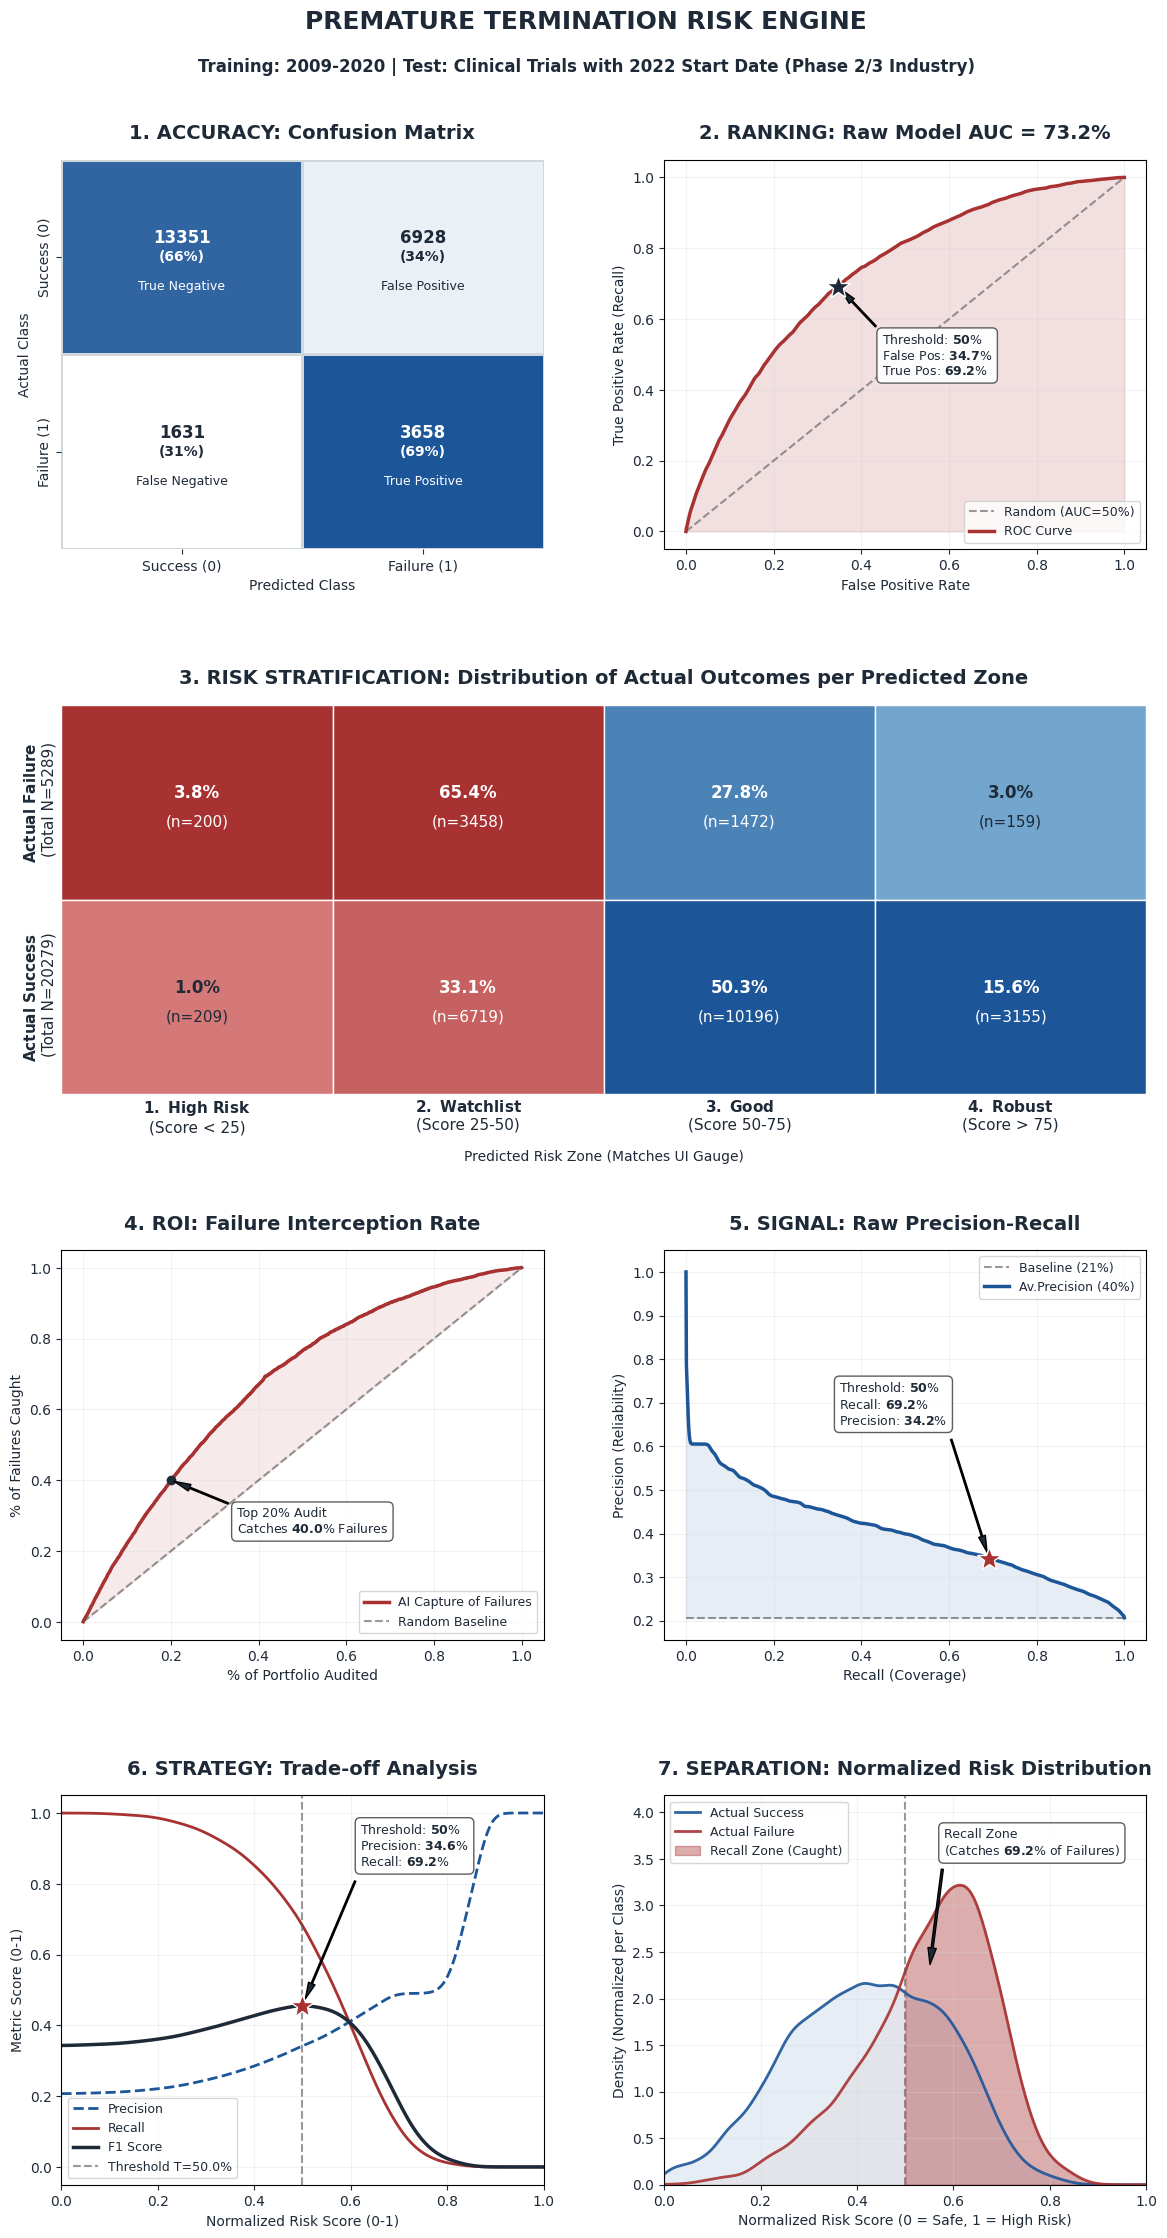

In [61]:
# <REF:PERF_VIS_CODE>
def plot_universal_professional_dashboard(y_true, y_scores_norm, y_scores_raw=None, threshold=0.5):
    """
    Generates the UI-Matched Data Science Dashboard.
    """
    if y_scores_raw is None:
        y_scores_raw = y_scores_norm

    # --- LAYOUT SETUP ---
    fig = plt.figure(figsize=(14, 25), facecolor='white')

    # Global Title
    fig.suptitle("PREMATURE TERMINATION RISK ENGINE",
                 fontsize=18, fontweight='bold', color=UI_COLORS['text_main'], y=0.98)
    fig.text(0.5, 0.955, "Training: 2009-2020 | Test: Clinical Trials with 2022 Start Date (Phase 2/3 Industry)",
             ha='center', fontsize=12, fontweight='bold', color=UI_COLORS['text_main'])

    # Grid Layout
    gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.25, top=0.92)

    ax1 = fig.add_subplot(gs[0, 0]) # Accuracy
    ax2 = fig.add_subplot(gs[0, 1]) # ROC
    ax3 = fig.add_subplot(gs[1, :]) # Matrix (Full Width)
    ax4 = fig.add_subplot(gs[2, 0]) # ROI
    ax5 = fig.add_subplot(gs[2, 1]) # PR Curve
    ax6 = fig.add_subplot(gs[3, 0]) # Strategy
    ax7 = fig.add_subplot(gs[3, 1]) # Separation

    # ==========================================================================
    # METRICS CALCULATION
    # ==========================================================================

    # 1. HYBRID STRATEGY (The actual Decision Policy)
    y_pred_hyb = (y_scores_norm >= threshold).astype(int)
    cm_hyb = confusion_matrix(y_true, y_pred_hyb)
    tn_h, fp_h, fn_h, tp_h = cm_hyb.ravel()

    rec_hyb = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0
    prec_hyb = tp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0
    fpr_hyb = fp_h / (tn_h + fp_h) if (tn_h + fp_h) > 0 else 0

    # 2. RAW MODEL FRONTIER (The Intelligence Curve)
    fpr_raw_arr, tpr_raw_arr, _ = roc_curve(y_true, y_scores_raw)
    p_raw_arr, r_raw_arr, _ = precision_recall_curve(y_true, y_scores_raw)

    # To place the star ON the line and keep numbers consistent with Panel 1:
    idx_roc = np.argmin(np.abs(tpr_raw_arr - rec_hyb))
    star_fpr = fpr_raw_arr[idx_roc]
    star_rec = tpr_raw_arr[idx_roc]

    idx_pr = np.argmin(np.abs(r_raw_arr - rec_hyb))
    star_prec = p_raw_arr[idx_pr]

    # ==========================================================================
    # PANEL 1: ACCURACY (Confusion Matrix)
    # ==========================================================================
    cm_perc = cm_hyb.astype('float') / cm_hyb.sum(axis=1)[:, np.newaxis]
    names = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]

    sns.heatmap(cm_perc, fmt="", cmap=cmap_conf, ax=ax1, cbar=False,
                linewidths=1, linecolor=UI_COLORS['grid_grey'])

    for i in range(2):
        for j in range(2):
            text_col = "white" if cm_perc[i, j] > 0.5 else UI_COLORS['text_main']
            ax1.text(j + 0.5, i + 0.4, f"{cm_hyb[i, j]}",
                     ha='center', va='center', color=text_col, fontsize=12, fontweight='bold')
            ax1.text(j + 0.5, i + 0.5, f"({cm_perc[i, j]:.0%})",
                     ha='center', va='center', color=text_col, fontsize=10, fontweight='bold')
            ax1.text(j + 0.5, i + 0.65, f"{names[i][j]}",
                     ha='center', va='center', color=text_col, fontsize=9)

    ax1.set_title(f"1. ACCURACY: Confusion Matrix", pad=15, color=UI_COLORS['text_main'])
    ax1.set_xlabel("Predicted Class")
    ax1.set_ylabel("Actual Class")
    ax1.set_xticklabels(['Success (0)', 'Failure (1)'])
    ax1.set_yticklabels(['Success (0)', 'Failure (1)'])

    # ==========================================================================
    # PANEL 2: RANKING (ROC Curve)
    # ==========================================================================
    roc_auc = auc(fpr_raw_arr, tpr_raw_arr)
    fpr_grid = np.linspace(0, 1, 1000)
    tpr_smooth = gaussian_filter1d(np.interp(fpr_grid, fpr_raw_arr, tpr_raw_arr), sigma=2)
    tpr_smooth[0], tpr_smooth[-1] = 0.0, 1.0

    ax2.plot([0, 1], [0, 1], label='Random (AUC=50%)', **ref_line_style)
    ax2.plot(fpr_grid, tpr_smooth, color=UI_COLORS['fail_deep'], lw=2.5, label=f'ROC Curve')
    ax2.fill_between(fpr_grid, tpr_smooth, alpha=0.15, color=UI_COLORS['fail_deep'])

    # Star on the line matching Strategy Recall
    ax2.plot(star_fpr, star_rec, marker='*', ms=18, color=UI_COLORS['text_main'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n inside the f-string for visual line breaks
    note = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
            fr"False Pos: $\mathbf{{{star_fpr*100:.1f}}}$%" + "\n"
            fr"True Pos: $\mathbf{{{star_rec*100:.1f}}}$%")
    ax2.annotate(note, xy=(star_fpr, star_rec), xytext=(star_fpr+0.1, star_rec-0.25),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)

    ax2.set_title(f"2. RANKING: Raw Model AUC = {roc_auc:.1%}", pad=15)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate (Recall)")
    ax2.legend(loc="lower right", frameon=True, fontsize=9)
    ax2.grid(True)

    # ==========================================================================
    # PANEL 3: RISK STRATIFICATION (VIBRANT GRADIENTS)
    # ==========================================================================
    df_matrix = pd.DataFrame({'target': y_true, 'prob': y_scores_norm})

    conditions = [
        (df_matrix['prob'] > 0.75),
        (df_matrix['prob'] > 0.50) & (df_matrix['prob'] <= 0.75),
        (df_matrix['prob'] > 0.25) & (df_matrix['prob'] <= 0.50),
        (df_matrix['prob'] <= 0.25)
    ]
    choices = ["1. High Risk", "2. Watchlist", "3. Good", "4. Robust"]
    df_matrix['Zone'] = np.select(conditions, choices, default="4. Robust")

    total_failures = df_matrix[df_matrix['target'] == 1].shape[0]
    total_successes = df_matrix[df_matrix['target'] == 0].shape[0]

    # FIXED: \n for proper headers
    row_labels_map = {
        0: fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})",
        1: fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})"
    }
    df_matrix['target_label'] = df_matrix['target'].map(row_labels_map)

    col_order = choices
    row_order = [
        fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})",
        fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})"
    ]

    matrix_pct = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'], normalize='index')[col_order] * 100
    matrix_counts = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'])[col_order]

    matrix_pct = matrix_pct.reindex(row_order).fillna(0)
    matrix_counts = matrix_counts.reindex(row_order).fillna(0)

    # FIXED: \n for zone descriptions
    detailed_labels = [
        fr"$\mathbf{{1.\ High\ Risk}}$" + "\n(Score < 25)",
        fr"$\mathbf{{2.\ Watchlist}}$" + "\n(Score 25-50)",
        fr"$\mathbf{{3.\ Good}}$" + "\n(Score 50-75)",
        fr"$\mathbf{{4.\ Robust}}$" + "\n(Score > 75)"
    ]

    rows = matrix_pct.index
    cols = matrix_pct.columns
    n_rows = len(rows)
    n_cols = len(cols)

    ax3.set_xlim(0, n_cols)
    ax3.set_ylim(0, n_rows)

    for j, col_label in enumerate(cols):
        if "High Risk" in col_label or "Watchlist" in col_label:
            current_cmap = cmap_fail
        else:
            current_cmap = cmap_succ

        val_fail = matrix_pct.loc[row_order[0], col_label]
        val_succ = matrix_pct.loc[row_order[1], col_label]
        max_val = max(val_fail, val_succ)
        if max_val == 0: max_val = 1.0

        for i, row_label in enumerate(rows):
            count = int(matrix_counts.loc[row_label, col_label])
            pct_display = matrix_pct.loc[row_label, col_label]

            intensity = pct_display / max_val
            # Start from 0.15 to keep light colors visible but clear
            rect_color = current_cmap(0.15 + (0.85 * intensity))

            rect = patches.Rectangle((j, n_rows - 1 - i), 1, 1, linewidth=1,
                                     edgecolor='white', facecolor=rect_color)
            ax3.add_patch(rect)

            text_color = 'white' if intensity > 0.5 else UI_COLORS['text_main']

            ax3.text(j + 0.5, n_rows - 1 - i + 0.55, f"{pct_display:.1f}%",
                     ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)
            ax3.text(j + 0.5, n_rows - 1 - i + 0.40, f"(n={count})",
                     ha='center', va='center', fontsize=11, fontweight='normal', color=text_color)

    ax3.set_xticks(np.arange(n_cols) + 0.5)
    ax3.set_xticklabels(detailed_labels, fontsize=11)
    ax3.set_yticks(np.arange(n_rows) + 0.5)
    ax3.set_yticklabels(rows[::-1], fontsize=11, rotation=90, va='center')
    ax3.set_title("3. RISK STRATIFICATION: Distribution of Actual Outcomes per Predicted Zone", pad=15)
    ax3.set_xlabel("Predicted Risk Zone (Matches UI Gauge)", labelpad=10)
    for spine in ax3.spines.values():
        spine.set_visible(False)
    ax3.tick_params(length=0)

    # ==========================================================================
    # PANEL 4: ROI
    # ==========================================================================
    data = pd.DataFrame({'target': y_true, 'prob': y_scores_norm}).sort_values('prob', ascending=False)
    data['cum_pop'] = np.arange(1, len(data) + 1) / len(data)
    data['cum_gain'] = data['target'].cumsum() / data['target'].sum()

    ax4.plot(data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], lw=2.5, label='AI Capture of Failures')
    ax4.plot([0, 1], [0, 1], label='Random Baseline', **ref_line_style)
    ax4.fill_between(data['cum_pop'], data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], alpha=0.1)

    idx_20 = (data['cum_pop'] - 0.20).abs().idxmin()
    gain_20 = data.loc[idx_20, 'cum_gain']
    ax4.plot(0.20, gain_20, 'o', color=UI_COLORS['text_main'], ms=6)

    # FIXED: \n for ROI note
    ax4.annotate(fr"Top 20% Audit" + "\n" + fr"Catches $\mathbf{{{gain_20*100:.1f}}}$% Failures",
                 xy=(0.20, gain_20), xytext=(0.35, gain_20 - 0.15),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax4.set_title("4. ROI: Failure Interception Rate", pad=15)
    ax4.set_xlabel("% of Portfolio Audited")
    ax4.set_ylabel("% of Failures Caught")
    ax4.legend(loc="lower right", frameon=True, fontsize=9)
    ax4.grid(True)

    # ==========================================================================
    # PANEL 5: SIGNAL
    # ==========================================================================
    ap = average_precision_score(y_true, y_scores_raw)
    base = y_true.mean()
    r_sort = np.argsort(r_raw_arr)
    p_mono = IsotonicRegression(increasing=False).fit_transform(r_raw_arr[r_sort], p_raw_arr[r_sort])
    r_dense = np.linspace(0, 1, 1000)
    p_smooth = gaussian_filter1d(np.interp(r_dense, r_raw_arr[r_sort], p_mono), sigma=3)
    p_smooth[0], p_smooth[-1] = 1.0, base

    ax5.plot([0, 1], [base, base], label=f'Baseline ({base:.0%})', **ref_line_style)
    ax5.plot(r_dense, p_smooth, color=UI_COLORS['succ_deep'], lw=2.5, label=f'Av.Precision ({ap:.0%})')
    ax5.fill_between(r_dense, p_smooth, base, color=UI_COLORS['succ_deep'], alpha=0.1)

    # Star on the line matching Strategy Recall
    ax5.plot(star_rec, star_prec, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for PR note
    note_pr = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
               fr"Recall: $\mathbf{{{star_rec*100:.1f}}}$%" + "\n"
               fr"Precision: $\mathbf{{{star_prec*100:.1f}}}$%")
    ax5.annotate(note_pr, xy=(star_rec, star_prec), xytext=(0.35, 0.65),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax5.set_title("5. SIGNAL: Raw Precision-Recall", pad=15)
    ax5.set_xlabel("Recall (Coverage)")
    ax5.set_ylabel("Precision (Reliability)")
    ax5.set_ylim(base-0.05, 1.05)
    ax5.legend(loc="upper right", frameon=True, fontsize=9)
    ax5.grid(True)

    # ==========================================================================
    # PANEL 6: STRATEGY
    # ==========================================================================
    p_trade, r_trade, t_trade = precision_recall_curve(y_true, y_scores_norm)
    p_trade, r_trade = p_trade[:-1], r_trade[:-1]
    t_grid = np.linspace(0, 1, 500)
    p_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=True).fit_transform(t_trade, p_trade)), sigma=10)
    r_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=False).fit_transform(t_trade, r_trade)), sigma=10)
    f1_smooth_line = 2*(p_smooth_line*r_smooth_line)/(p_smooth_line+r_smooth_line+1e-8)

    ax6.plot(t_grid, p_smooth_line, color=UI_COLORS['succ_deep'], linestyle='--', lw=2, label="Precision")
    ax6.plot(t_grid, r_smooth_line, color=UI_COLORS['fail_deep'], linestyle='-', lw=2, label="Recall")
    ax6.plot(t_grid, f1_smooth_line, color=UI_COLORS['text_main'], linestyle='-', lw=2.5, label="F1 Score")
    ax6.axvline(threshold, label=f'Threshold T={threshold:.1%}', **ref_line_style)

    idx_thresh = np.argmin(np.abs(t_grid - threshold))
    f1_at_thresh = f1_smooth_line[idx_thresh]
    ax6.plot(threshold, f1_at_thresh, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for Strategy note
    strat_text = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
                  fr"Precision: $\mathbf{{{prec_hyb*100:.1f}}}$%" + "\n"
                  fr"Recall: $\mathbf{{{rec_hyb*100:.1f}}}$%")
    ax6.annotate(strat_text, xy=(threshold, f1_at_thresh), xytext=(0.62, 0.85),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax6.set_title("6. STRATEGY: Trade-off Analysis", pad=15)
    ax6.set_xlabel("Normalized Risk Score (0-1)")
    ax6.set_ylabel("Metric Score (0-1)")
    ax6.legend(loc="lower left", frameon=True, fontsize=9)
    ax6.grid(True)
    ax6.set_xlim(0, 1.0)

    # ==========================================================================
    # PANEL 7: SEPARATION
    # ==========================================================================
    x_grid = np.linspace(0, 1, 500)
    kde_succ = gaussian_kde(y_scores_norm[y_true == 0])
    kde_fail = gaussian_kde(y_scores_norm[y_true == 1])
    y_succ_balanced = kde_succ(x_grid)
    y_fail_balanced = kde_fail(x_grid)

    ax7.plot(x_grid, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.9, lw=2, label='Actual Success')
    ax7.fill_between(x_grid, 0, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.1)
    ax7.plot(x_grid, y_fail_balanced, color=UI_COLORS['fail_deep'], alpha=0.9, lw=2, label='Actual Failure')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid >= threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.4, label='Recall Zone (Caught)')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid < threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.05)
    ax7.axvline(threshold, **ref_line_style)

    max_density = max(y_succ_balanced.max(), y_fail_balanced.max())
    ax7.set_ylim(0, max_density * 1.3)

    # FIXED: \n for Separation note
    ax7.annotate(fr"Recall Zone" + "\n" + fr"(Catches $\mathbf{{{rec_hyb*100:.1f}}}$% of Failures)",
                        xy=(threshold + 0.05, y_fail_balanced[np.argmin(np.abs(x_grid - threshold))]),
                        xytext=(0.58, max_density * 1.1),
                        arrowprops=dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1.5, headwidth=6),
                        bbox=box_style, fontsize=9)
    ax7.set_title("7. SEPARATION: Normalized Risk Distribution", pad=15)
    ax7.set_xlabel("Normalized Risk Score (0 = Safe, 1 = High Risk)")
    ax7.set_ylabel("Density (Normalized per Class)")
    ax7.legend(loc="upper left", frameon=True, fontsize=9)
    ax7.grid(True)
    ax7.set_xlim(0, 1.0)

    plt.show()

# --- EXECUTE ---
print(">>> Rendering Final UI-Matched Dashboard...")
# --- SYNC LOGIC: Forced Data Refresh ---
# We re-patch test_results here to ensure strategy changes flow into the plots.
df_audit_vis = df_audit.copy()

df_audit_vis['proba_1'] = y_prob_audit
df_audit_vis['risk_score_norm'] = 1.0 - (df_full_scores.loc[df_audit_vis.index, 'Clinical_Score'] / 100.0)

plot_universal_professional_dashboard(
    y_true=df_audit_vis['target'],
    y_scores_norm=df_audit_vis['risk_score_norm'],
    y_scores_raw=df_audit_vis['proba_1'],
    threshold=0.5
)
# <REF:/PERF_VIS_CODE>


#### <REF:UI_VIS>
> #### **14. Individual Trial Profiler: Production APP UI Snapshot**

This module demonstrates the individual-level output used in the production application. The **Clinical Success Score** is presented via a vibrant gauge, providing instant visual context—from 'High Risk' (Red) to 'Robust' (Gold)—to support rapid, high-confidence decision-making.

In [62]:
# <REF:UI_VIS_CODE>
Trial_Example = 350

print(f"\n>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID {Trial_Example}...")


import plotly.graph_objects as go
import pandas as pd
import numpy as np
import re
import textwrap

# ==============================================================================
# 0. UNIFIED STYLE CONFIGURATION (VIBRANT PROFESSIONAL)
# ==============================================================================
STYLE_CONFIG = {
    "font_family": "Arial",
    "font_size_header": 16,
    "font_size_body": 14,
    "font_color": "#1f2a38",
    "colors": {
        "red_deep":   (168, 50, 50),
        "red_soft":   (240, 163, 163),
        "grey_warm":  (242, 244, 248),
        "blue_soft":  (154, 203, 232),
        "blue_deep":  (28, 86, 153),
        "therapeutic_grey": "#CFD8DC",
        "separator_white": "white"
    }
}

def get_rgb_str(rgb_tuple):
    return f"rgb({rgb_tuple[0]},{rgb_tuple[1]},{rgb_tuple[2]})"

def interpolate_color(c1, c2, ratio):
    r = int(c1[0] + (c2[0] - c1[0]) * ratio)
    g = int(c1[1] + (c2[1] - c1[1]) * ratio)
    b = int(c1[2] + (c2[2] - c1[2]) * ratio)
    return (r, g, b)

def mix_white(rgb, factor=0.7):
    r, g, b = rgb
    new_r = int(r + (255 - r) * factor)
    new_g = int(g + (255 - g) * factor)
    new_b = int(b + (255 - b) * factor)
    return (new_r, new_g, new_b)

def fmt_header(text, value, txt_color="black", split=False):
    label = f"{text}<br>({value:+.1f}%)" if split else f"{text} ({value:+.1f}%)"
    return f"<span style='font-size:14px; font-weight:bold; color:{txt_color}'>{label}</span>"

# ==============================================================================
# 1. GAUGE CHART
# ==============================================================================
print("\n=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===")

def plot_risk_gauge(score_val):
    steps = []
    c = STYLE_CONFIG["colors"]
    for i in range(100):
        if i < 25: color = interpolate_color(c["red_deep"], c["red_soft"], i / 25.0)
        elif i < 50: color = interpolate_color(c["red_soft"], c["grey_warm"], (i - 25) / 25.0)
        elif i < 75: color = interpolate_color(c["grey_warm"], c["blue_soft"], (i - 50) / 25.0)
        else: color = interpolate_color(c["blue_soft"], c["blue_deep"], (i - 75) / 25.0)
        steps.append({'range': [i, i + 1], 'color': get_rgb_str(color)})
    for sep in [25, 50, 75]: steps.append({'range': [sep - 0.5, sep + 0.5], 'color': 'white'})

    fig = go.Figure(go.Indicator(
        mode="gauge+number", value=score_val,
        number={"valueformat": ".1f", "font": {"size": 52, "color": STYLE_CONFIG["font_color"], "family": STYLE_CONFIG["font_family"], "weight": "bold"}},
        domain={"x": [0, 1], "y": [0, 1]},
        gauge={
            "axis": {"range": [0, 100], "tickmode": "array", "tickvals": [0, 25, 50, 75, 100], "tickfont": {"size": 14, "color": "#555555", "family": "Arial", "weight": "bold"}},
            "bar": {"color": "rgba(0,0,0,0)"}, "bgcolor": "white", "borderwidth": 0, "steps": steps,
            "threshold": {"line": {"color": STYLE_CONFIG["font_color"], "width": 5}, "thickness": 0.75, "value": score_val},
        },
    ))
    fig.update_layout(margin=dict(l=35, r=35, t=40, b=10), height=220, paper_bgcolor="white", hovermode=False)
    return fig

# ==============================================================================
# 2. IMPACT BAR CHART
# ==============================================================================
print("\n=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===")

def get_pillar_impacts(df_full_scores, trial_index):
    meta_cols = ['Clinical_Score', 'Therapeutic_Area', 'Phase', 'Internal_Score_Raw', 'Zone', 'CALIBRATION_OFFSET']
    pillar_cols = [c for c in df_full_scores.columns if c not in meta_cols]
    row = df_full_scores.loc[trial_index, pillar_cols].copy()
    df_impact = pd.DataFrame({'Pillar': row.index, 'Impact': row.values})
    df_impact['Pillar_Clean'] = df_impact['Pillar'].apply(lambda x: re.sub(r'^\d+\.\s*', '', x))
    df_impact['Label'] = df_impact['Impact'].apply(lambda x: f"{x:+.1f}%")
    return df_impact.sort_values(by='Impact', ascending=True)

def plot_impact_bar(df_impact, trial_id, score):
    max_val = df_impact['Impact'].abs().max()
    limit, BAR_WIDTH, SLICE_STEP, GLOBAL_MAX_SCALE = max_val * 1.35, 0.75, 0.08, 4.0
    c = STYLE_CONFIG["colors"]
    fig = go.Figure()
    for i in range(int(np.ceil(max_val / SLICE_STEP))):
        pos = i * SLICE_STEP
        widths, colors, texts = [], [], []
        for val in df_impact['Impact']:
            abs_v = abs(val)
            if pos >= abs_v: w, is_tip = 0, False
            elif pos + SLICE_STEP > abs_v: w, is_tip = abs_v - pos, True
            else: w, is_tip = SLICE_STEP, False
            widths.append(-w if val < 0 else w)
            texts.append(f"{val:+.1f}%" if is_tip else None)
            ratio = min((pos + abs(w)/2) / GLOBAL_MAX_SCALE, 1.0) ** 0.5
            if val >= 0:
                final_rgb = interpolate_color(c["grey_warm"], c["blue_soft"], ratio*2) if ratio < 0.5 else interpolate_color(c["blue_soft"], c["blue_deep"], (ratio-0.5)*2)
            else:
                final_rgb = interpolate_color(c["grey_warm"], c["red_soft"], ratio*2) if ratio < 0.5 else interpolate_color(c["red_soft"], c["red_deep"], (ratio-0.5)*2)
            colors.append(get_rgb_str(final_rgb))
        fig.add_trace(go.Bar(y=df_impact['Pillar_Clean'], x=widths, orientation='h', width=BAR_WIDTH, marker=dict(color=colors, line=dict(width=0)), text=texts, textposition='outside', textfont=dict(size=12, color="black"), hoverinfo='skip', showlegend=False))
    fig.add_vline(x=0, line_width=1, line_color="#333333")
    fig.update_layout(barmode='relative', xaxis=dict(showticklabels=False, range=[-limit, limit]), yaxis=dict(automargin=True), margin=dict(l=10, r=10, t=50, b=10), height=300, paper_bgcolor="white", plot_bgcolor="white")
    return fig

# ==============================================================================
# 3. TREEMAP
# ==============================================================================
print("\n=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===")

def plot_smart_treemap(shap_values, feature_names, trial_index, taxonomy, gain_factor, df_full_scores, df_raw):
    # ROBUST DATA ACCESS
    if df_raw.index.name != 'nct_id':
        if 'nct_id' in df_raw.columns:
            trial_data = df_raw[df_raw['nct_id'] == trial_index].iloc[0]
        else:
            return go.Figure()
    else:
        trial_data = df_raw.loc[trial_index]

    try:
        pos_idx = df_full_scores.index.get_loc(trial_index)
        row_shap = shap_values[pos_idx]
        calib_credit = df_full_scores.loc[trial_index, "CALIBRATION_OFFSET"]
    except:
        return go.Figure()

    nodes, node_sums, c, leaf_data = {}, {"ALL_DRIVERS": 0.0}, STYLE_CONFIG["colors"], []
    nodes["ALL_DRIVERS"] = {"parent": "", "label": "ALL DRIVERS", "color": "#FFFFFF", "value": 0}

    for pillar_raw, topics in taxonomy.items():
        pillar_clean = pillar_raw.split(". ")[-1]
        p_id = f"PILLAR_{pillar_clean}"
        nodes[p_id] = {"parent": "ALL_DRIVERS", "label": pillar_clean.upper(), "color": "#ECEFF1", "value": 0}
        node_sums[p_id] = 0.0

        for subtopic, details in topics.items():
            f_keys_list, f_labels_list = details["features"], details["feature_labels"]
            impact, feat_strings = 0.0, []

            for f_keys, f_label in zip(f_keys_list, f_labels_list):
                if not isinstance(f_keys, list): f_keys = [f_keys]
                sub_impact, val_parts = 0.0, []

                for k in f_keys:
                    # 1. Calculation
                    if k == "CALIBRATION_OFFSET":
                        sub_impact += calib_credit
                        val_parts.append(str(trial_data.get("therapeutic_area_ui", "N/A")))
                    else:
                        # Find SHAP (if active)
                        idx_f = next((i for i, f in enumerate(feature_names) if f == k), None)
                        if idx_f is not None:
                            sub_impact += (row_shap[idx_f] * gain_factor * -1)

                        # 2. Value Lookup (even if SHAP is 0/disabled)
                        # Remove prefixes to find raw column name
                        raw_k = k.replace("ordinal__", "").replace("target__", "").replace("num_arms__", "").replace("num_duration__", "")
                        ui_col = raw_k.replace("_ml", "_ui")
                        if "gbd_cause_id_3" in raw_k: ui_col = "gbd_indication_name"

                        val = trial_data.get(ui_col, "N/A")
                        if isinstance(val, float): val = f"{val:.1f}"
                        val_parts.append(str(val))

                impact += sub_impact
                feat_strings.append(f"{f_label}: <b>{' / '.join(val_parts)}</b>")

            ratio = max(0.15, min(abs(impact) / 8.0, 1.0))
            color = interpolate_color(c["blue_soft"], c["blue_deep"], ratio) if impact >= 0 else interpolate_color(c["red_soft"], c["red_deep"], ratio)

            label_html = (f"<span style='font-size:15px; font-weight:bold; color:white'>{subtopic}</span>"
                          f"<br><span style='font-size:14px; color:white'>{impact:+.1f}%</span>"
                          f"<br><br><span style='font-size:11px; color:white'>• {'<br>• '.join(feat_strings)}</span>")

            leaf_id = f"{p_id}_{subtopic}"
            node_sums[p_id] += impact
            node_sums["ALL_DRIVERS"] += impact
            leaf_data.append({"id": leaf_id, "parent": p_id, "label": label_html, "color": get_rgb_str(color), "value": max(0.5, abs(impact))})

    for p_id, val in node_sums.items():
        if p_id == "ALL_DRIVERS": nodes[p_id]["label"] = fmt_header("ALL DRIVERS", val)
        else:
            nodes[p_id]["label"] = fmt_header(nodes[p_id]["label"], val)
            nodes[p_id]["color"] = get_rgb_str(mix_white(interpolate_color(c["blue_soft" if val >= 0 else "red_soft"], c["blue_deep" if val >= 0 else "red_deep"], min(abs(val)/8.0, 1.0))))

    for item in leaf_data: nodes[item["id"]] = item
    ids = list(nodes.keys())
    fig = go.Figure(go.Treemap(ids=ids, labels=[nodes[k]["label"] for k in ids], parents=[nodes[k]["parent"] for k in ids], values=[nodes[k]["value"] for k in ids], marker=dict(colors=[nodes[k]["color"] for k in ids], line=dict(width=1, color="white")), textinfo="label", textposition="top left"))
    fig.update_layout(margin=dict(t=34, l=15, r=15, b=15), height=600, paper_bgcolor="white", hovermode=False)
    return fig

# ==============================================================================
# 4. EXECUTION
# ==============================================================================
# Set index for lookup parity
if df_full.index.name != 'nct_id':
    df_full = df_full.set_index('nct_id')

target_idx = df_full_scores.index[Trial_Example]
score_val = df_full_scores.loc[target_idx, 'Clinical_Score']

fig_gauge = plot_risk_gauge(score_val)
fig_gauge.show()

fig_bar = plot_impact_bar(get_pillar_impacts(df_full_scores, target_idx), target_idx, score_val)
fig_bar.show()

fig_tree = plot_smart_treemap(shap_values, feature_names, target_idx, RISK_TAXONOMY, GAIN_FACTOR, df_full_scores, df_full)
fig_tree.show()

# <REF:/UI_VIS_CODE>



>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID 350...

=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===

=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===

=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===


# **Production Engine: Final Deployment & Artifact Manifest**

### **1. Consolidated Artifact Inventory**
The Production Engine generates a suite of artifacts distributed across two primary service layers. Mathematical scoring is centralized in the API for absolute consistency, while the user experience remains fast and responsive in the Frontend.

| Artifact | Storage Location | Content Description | Consumption Layer |
| :--- | :--- | :--- | :--- |
| **Production Model** | `models/model_prod_01.joblib` | Final Scikit-learn Pipeline (Preprocessor + XGBClassifier) trained on 2009–2022 historical cohort. | **FastAPI** (`api/main.py`) |
| **Threshold Logic** | `models/thresholds_01.json` | Recency-weighted decision boundaries (logits) and calibration constants (Gain Factor, Intercept). | **FastAPI** (`api/main.py`) |
| **SHAP Store** | `models/shap_values_01.joblib` | Pre-calculated feature attributions for all ~30,000 trials, enabling instant "Audit Mode" lookups. | **FastAPI** (`api/main.py`) |
| **Taxonomy Logic** | `models/taxonomy_01.json` | Logic-locked snapshot of Feature Registry and UI Schema to ensure API/UI alignment. | **FastAPI** (`api/main.py`) |
| **Search Registry** | `frontend/data/search_registry.csv` | Full trial universe enriched with success scores, zones, and scientific narratives for the search interface. | **Streamlit** (`frontend/app.py`) |

### **2. Production Engine Summary**
*   **Engine Maturity:** The model utilizes the full historical signal (2009–2022) with **Recency Weighting** (linear gradient 0.1 to 1.0) to prioritize contemporary R&D success patterns.
*   **Success Orientation:** All raw risk probabilities are transformed into a **0–100 Success Score** where **50.0** is the specific TA decision boundary.
*   **Pillar Attribution:** SHAP values are aggregated into four strategic pillars (**Therapeutic Context**, **Scientific Design**, **Execution Framework**, **Patient Profile**) for root-cause explainability.

### **3. Interaction Workflow: The "Handshake"**
The interaction between components follows a **UI-Driven Audit** model:
1.  **Discovery (Streamlit):** Users filter and search trials using the local `search_registry.csv`. This allows for "search-as-you-type" performance without API overhead.
2.  **Handshake (Streamlit -> FastAPI):** When a trial is selected, Streamlit sends the `nct_id` and `therapeutic_area` to the API.
3.  **Scoring (FastAPI):** The API looks up the trial's specific SHAP values and TA threshold. It reconstructs the **Success Score (0-100)** and pillar impacts.
4.  **Visualization (FastAPI -> Streamlit):** The API returns the score and aggregated attributions, which Streamlit renders as the **Gauge**, **Treemap**, and **Impact Bars**.

### **4. Strategic Rationale: "The Why"**
*   **"Audit Mode" Primacy:** By pre-calculating SHAP values, we eliminate environment-driven drift (BioBERT versioning) and reduce API latency from seconds to milliseconds.
*   **Mathematical Truth:** Centralizing scoring logic in FastAPI ensures that all UI visualizations (Gauge, Treemap) are bit-perfectly aligned using the same calibration offsets.
*   **Isolated Performance:** Keeping the search database in the frontend container allows the system to scale horizontally, handling thousands of concurrent searches without stressing the inference engine.

### **5. Deployment Architecture Verification**
- **API Synchronization:** The FastAPI layer in `api/main.py` is configured to load all logic artifacts directly from the root `models/` directory.
- **Frontend Isolation:** The Streamlit app in `frontend/app.py` consumes its data from the local `frontend/data/` path, ensuring the UI remains performant and easy to package for deployment.
- **Backward Compatibility:** While historical files like `app_search_data_01.csv` may exist in `models/`, the production engine now defaults to `search_registry.csv` to align with the finalized UI naming convention.


#### <REF:PROD_EXPORT>
> #### **9. Production Artifact Persistence & Optimized UI Sync**

This module finalizes the model artifacts for deployment and creates the **Surgical-Lean Search Registry**.
*   **Model Store**: Saves `model_prod_01.joblib` (Pickle), `thresholds_01.json`, and `taxonomy_01.json`.
*   **Discovery Engine (`search_registry.csv`)**: 
    *   **97% Compression**: Strips 2,300+ embedding columns to reduce file size from 170MB to ~55MB.
    *   **Rich Search Identity**: Synthesizes drug, sponsor, acronym, and year into one searchable label.
    *   **Demo-Mode Integrity**: Pre-calculates the `is_correct` flag to allow instant showcase of model-validated historical results.


In [63]:
import pandas as pd
import json
import joblib
import numpy as np
import csv
from pathlib import Path
from src.prep.data_loader_clinpred import ClinicalTrialLoader

# <REF:PROD_EXPORT_CODE_V4>
# 1. EXPORT TAXONOMY AS SOURCE OF TRUTH (Syncs API and UI)
from src.prep.pipeline import export_pipeline_taxonomy
taxonomy_path = MODELS_PATH / "taxonomy_01.json"
export_pipeline_taxonomy(taxonomy_path)

# --- 2. CUSTOM PORTFOLIO KNOBS (EDIT HERE) ---
# Filter for the Search Registry (CSV) only.
BIG_PHARMA = ['NOVARTIS', 'GSK', 'PFIZER', 'MERCK (USA)', 'ROCHE', 'J&J', 'SANOFI', 'LILLY', 'AZN', 'AMGEN']
MIN_YEAR = 2019

# 3. ENHANCED SEARCH IDENTITY
def create_search_label(row):
    acro = str(row['acronym']).strip() if pd.notna(row['acronym']) else ""
    drug = str(row['alpha_drug_name']).strip() if pd.notna(row['alpha_drug_name']) else "Unknown Drug"
    sponsor = str(row['lead_sponsor_canonical']).strip() if pd.notna(row['lead_sponsor_canonical']) else "Unknown Sponsor"

    # MANDATE: Use therapeutic_area_ui for proper-case display
    ta_val = row.get('therapeutic_area_ui')
    if pd.isna(ta_val) or str(ta_val).strip().upper() in ['NAN', 'N/A', '']:
        ta_val = row.get('therapeutic_area', 'Unclassified')
    ta = str(ta_val).strip()

    year = str(int(row['start_year'])) if pd.notna(row['start_year']) else "YYYY"
    prefix = f"[{acro}] " if acro and acro.lower() != 'nan' else ""
    return f"{prefix}{drug} ({sponsor}) | {ta} ({year})"

if df_full.index.name == 'nct_id':
    df_full = df_full.reset_index()
print(">>> Generating Search Identities...")
df_full['ui_search_label'] = df_full.apply(create_search_label, axis=1)

# 4. BACKTESTING VERIFICATION LOGIC (Demo Accuracy)
def check_accuracy(row):
    if pd.isna(row.get('target')): return None
    target = row['target']
    score = row.get('Clinical_Score', 0)
    if (score >= 50.0 and target == 0.0) or (score < 50.0 and target == 1.0):
        return True
    return False

df_full['is_correct'] = df_full.apply(check_accuracy, axis=1)

# 5. EXPORT FILTERED REGISTRY
REGISTRY_PATH = FRONTEND_DATA_PATH / "search_registry.csv"
print(f">>> Applying Custom Filter for CSV: {len(BIG_PHARMA)} companies after {MIN_YEAR}...")

# Filter a copy for the CSV export
df_registry = df_full[
    (df_full['lead_sponsor_canonical'].isin(BIG_PHARMA)) &
    (df_full['start_year'] > MIN_YEAR)
].copy()

if 'nct_id' in df_registry.columns:
    df_registry = df_registry.set_index('nct_id')

print(f">>> Exporting Filtered Registry: {len(df_registry):,} trials to {REGISTRY_PATH}")
df_registry.to_csv(REGISTRY_PATH, index=True, quoting=csv.QUOTE_ALL)

# 6. SERIALIZE PRODUCTION ARTIFACTS (Full Universe)
print(">>> Persisting Production Artifacts to /models...")
joblib.dump(model, MODELS_PATH / "model_prod_01.joblib")

# Ensure nct_id is index for SHAP dictionary mapping
if df_full.index.name != 'nct_id':
    df_full = df_full.set_index('nct_id')

if len(df_full) == len(shap_values):
    # This dictionary remains full (30k trials) but maps correctly via NCT_ID
    shap_dict = dict(zip(df_full.index.astype(str), shap_values))
    joblib.dump(shap_dict, MODELS_PATH / "shap_values_01.joblib")
    print(f"   - SHAP Store: {MODELS_PATH / 'shap_values_01.joblib'} ({len(shap_dict)} trials)")

with open(MODELS_PATH / "thresholds_01.json", 'w') as f:
    cal_arts['base_value'] = float(model_base_value)
    json.dump(cal_arts, f, indent=4)

print("✅ All artifacts persisted. Production Engine Ready.")
print(f"   - Model:      {MODELS_PATH / 'model_prod_01.joblib'}")
print(f"   - Registry:   {REGISTRY_PATH}")


✅ Integrated Taxonomy exported to /home/delaunan/code/delaunan/clintrialpredict/models/taxonomy_01.json
>>> Generating Search Identities...
>>> Applying Custom Filter for CSV: 10 companies after 2019...
>>> Exporting Filtered Registry: 1,496 trials to /home/delaunan/code/delaunan/clintrialpredict/frontend/data/search_registry.csv
>>> Persisting Production Artifacts to /models...
   - SHAP Store: /home/delaunan/code/delaunan/clintrialpredict/models/shap_values_01.joblib (29556 trials)
✅ All artifacts persisted. Production Engine Ready.
   - Model:      /home/delaunan/code/delaunan/clintrialpredict/models/model_prod_01.joblib
   - Registry:   /home/delaunan/code/delaunan/clintrialpredict/frontend/data/search_registry.csv
